### 1. Install & Setup

In [12]:
%pip install pyspark

Note: you may need to restart the kernel to use updated packages.


### 2. Import & Inisialisasi Spark

In [2]:
import os
os.environ['JAVA_TOOL_OPTIONS'] = '-Djava.security.manager=allow'

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("NYC Taxi Fare Prediction") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

### 3. Load Data

In [3]:
df = spark.read.csv("train.csv", header=True, inferSchema=True)

df.printSchema()
df.show(5)
print("Total rows:", df.count())

root
 |-- key: timestamp (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- passenger_count: integer (nullable = true)

+-------------------+-----------+-------------------+----------------+---------------+-----------------+----------------+---------------+
|                key|fare_amount|    pickup_datetime|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|passenger_count|
+-------------------+-----------+-------------------+----------------+---------------+-----------------+----------------+---------------+
|2009-06-15 17:26:21|        4.5|2009-06-16 00:26:21|      -73.844311|      40.721319|        -73.84161|       40.712278|              1|
|2010-01-05 16:52:16|       16.9|2010-01-05 23:52:16|      -74.016048| 

### 4. Statistik Deskriptif

In [4]:
df.describe(['fare_amount', 'passenger_count', 
             'pickup_longitude', 'pickup_latitude',
             'dropoff_longitude', 'dropoff_latitude']).show()

+-------+------------------+------------------+------------------+-----------------+------------------+------------------+
|summary|       fare_amount|   passenger_count|  pickup_longitude|  pickup_latitude| dropoff_longitude|  dropoff_latitude|
+-------+------------------+------------------+------------------+-----------------+------------------+------------------+
|  count|          55423856|          55423856|          55423856|         55423856|          55423480|          55423480|
|   mean|11.345045601663852|1.6853799201556816|-72.50968444358729| 39.9197917868882|-72.51120972971809|39.920681444828844|
| stddev|  20.7108321982325|1.3276643570959683| 12.84888338140265|9.642353041994934|12.782196517830771| 9.633345796415124|
|    min|            -300.0|                 0|      -3442.059565|     -3492.263768|      -3442.024565|      -3547.886698|
|    max|          93963.36|               208|       3457.625683|      3408.789565|        3457.62235|       3537.132528|
+-------+-------

In [5]:
from pyspark.sql.functions import col, count, when, isnan

df.select([
    count(when(col(c).isNull(), c)).alias(c) 
    for c in df.columns
]).show()

+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+
|key|fare_amount|pickup_datetime|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|passenger_count|
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+
|  0|          0|              0|               0|              0|              376|             376|              0|
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+



In [6]:
df_sample = df.sample(fraction=0.01, seed=42).toPandas()
print("Sample size:", len(df_sample))

Sample size: 555381


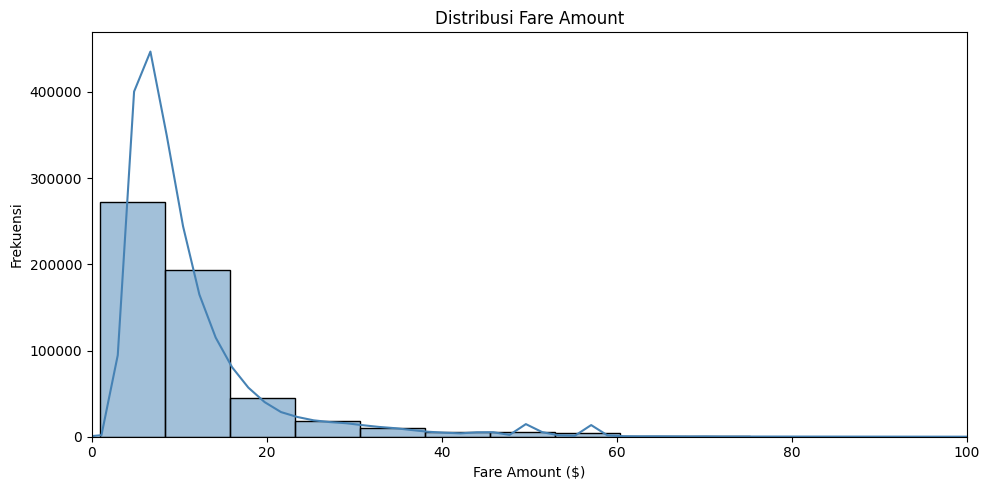

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df_sample['fare_amount'], bins=50, kde=True, color='steelblue')
plt.title('Distribusi Fare Amount')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Frekuensi')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

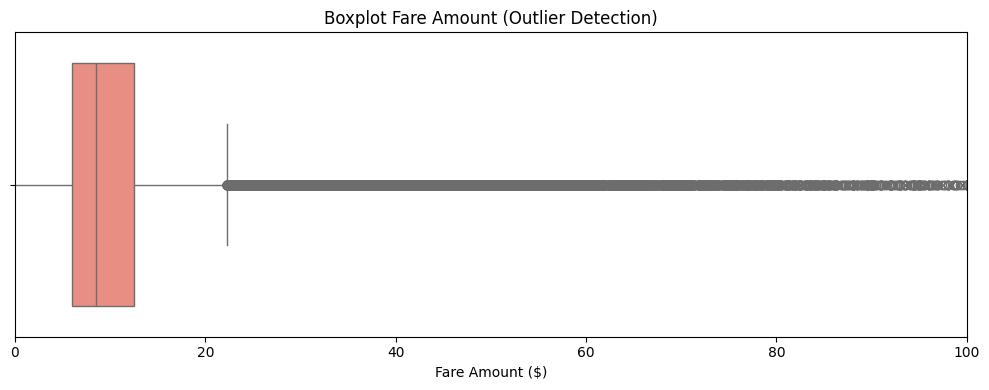

In [8]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_sample['fare_amount'], color='salmon')
plt.title('Boxplot Fare Amount (Outlier Detection)')
plt.xlabel('Fare Amount ($)')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_81948\2617272415.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='passenger_count', data=df_sample, palette='viridis')


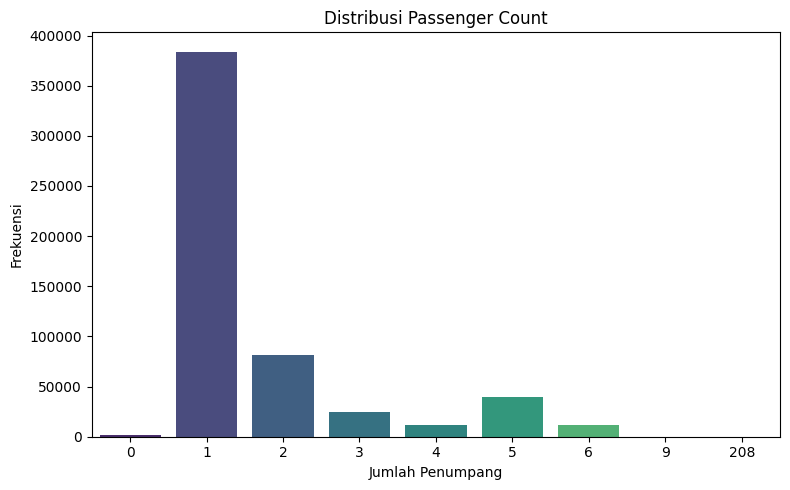

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x='passenger_count', data=df_sample, palette='viridis')
plt.title('Distribusi Passenger Count')
plt.xlabel('Jumlah Penumpang')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

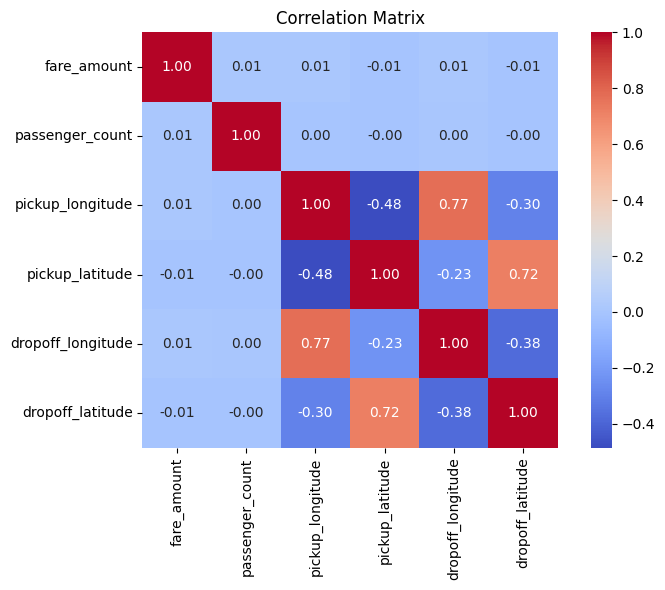

In [10]:
import numpy as np

numeric_cols = ['fare_amount', 'passenger_count', 
                'pickup_longitude', 'pickup_latitude',
                'dropoff_longitude', 'dropoff_latitude']

corr_matrix = df_sample[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
            cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_81948\2919563202.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


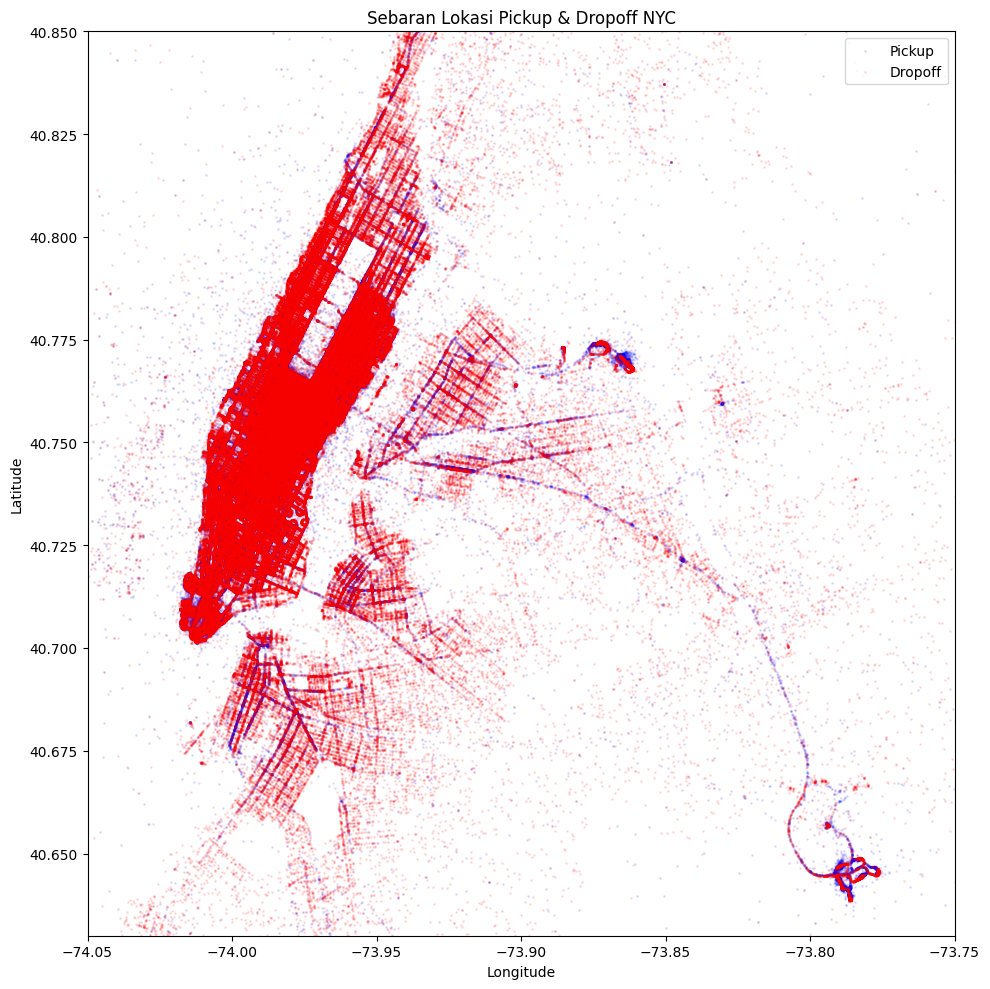

In [11]:
plt.figure(figsize=(10, 10))
plt.scatter(df_sample['pickup_longitude'], 
            df_sample['pickup_latitude'], 
            alpha=0.1, s=1, color='blue', label='Pickup')
plt.scatter(df_sample['dropoff_longitude'], 
            df_sample['dropoff_latitude'], 
            alpha=0.1, s=1, color='red', label='Dropoff')
plt.title('Sebaran Lokasi Pickup & Dropoff NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-74.05, -73.75)
plt.ylim(40.63, 40.85)
plt.legend()
plt.tight_layout()
plt.show()